### Avaliação de imóveis

In [1]:
# Importando bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
imoveis = pd.read_csv('Valorizacao_Ambiental.csv', sep=';')

In [3]:
imoveis.head()

,Ordem,Valor,Area,IA,Andar,Suites,Vista,DistBM,Semruido,AV100m
0,1,160000,168,1,5,1,1,294,1,0
1,2,67000,129,1,6,0,0,1505,1,0
2,3,190000,218,1,8,1,0,251,0,1
3,4,110000,180,12,4,1,0,245,0,0
4,5,70000,120,15,3,1,0,956,1,0


In [4]:
# Verificando o tamanho da base
imoveis.shape

(172, 10)

In [5]:
# Verificando se tem valores nulos
imoveis.isnull().sum()

Ordem       0
Valor       0
Area        0
IA          0
Andar       0
Suites      0
Vista       0
DistBM      0
Semruido    0
AV100m      0
dtype: int64

In [6]:
# Verificando as estatísticas descritivas
imoveis.describe().round(2)

,Ordem,Valor,Area,IA,Andar,Suites,Vista,DistBM,Semruido,AV100m
count,172.00,172.00,172.00,172.00,172.00,172.00,172.00,172.00,172.00,172.00
mean,86.50,173541.95,163.20,5.65,4.30,1.40,0.14,505.89,0.58,0.35
std,49.80,99827.09,65.92,5.57,2.24,1.13,0.35,395.05,0.49,0.48
min,1.00,40000.00,69.00,1.00,1.00,0.00,0.00,73.00,0.00,0.00
25%,43.75,104750.00,117.00,1.00,2.75,1.00,0.00,214.75,0.00,0.00
50%,86.50,149000.00,145.00,2.50,4.00,1.00,0.00,402.50,1.00,0.00
75%,129.25,209250.00,182.00,11.00,6.00,2.00,0.00,638.00,1.00,1.00
max,172.00,579840.00,393.00,19.00,12.00,6.00,1.00,1859.00,1.00,1.00


### Identificando a variável target(Variável resposta)

Text(0.5, 1.0, 'Histograma da variável valor')

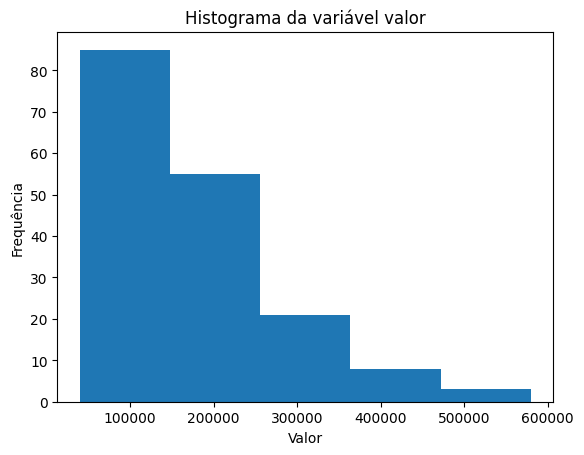

In [7]:
plt.hist(imoveis["Valor"], bins=5)

plt.ylabel("Frequência")
plt.xlabel("Valor")

plt.title("Histograma da variável valor")

In [8]:
# Criando a variável raiz_valor usando a raiz quadrada
imoveis["raiz_valor"] = np.sqrt(imoveis["Valor"])

Text(0.5, 1.0, 'Histograma da variável valor após raiz quadrada')

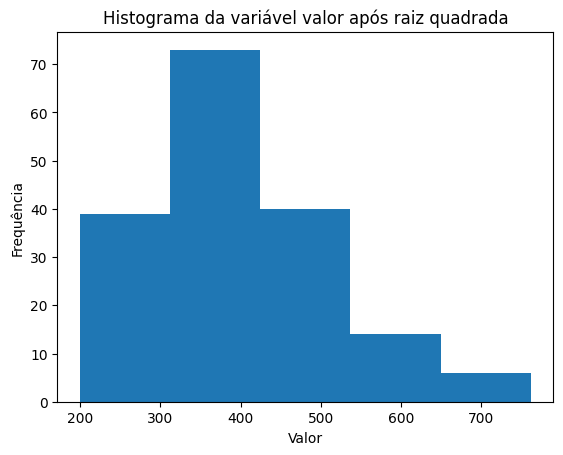

In [9]:
plt.hist(imoveis["raiz_valor"], bins=5)

plt.ylabel("Frequência")
plt.xlabel("Valor")

plt.title("Histograma da variável valor após raiz quadrada")

Text(0, 0.5, 'Qtd de suites')

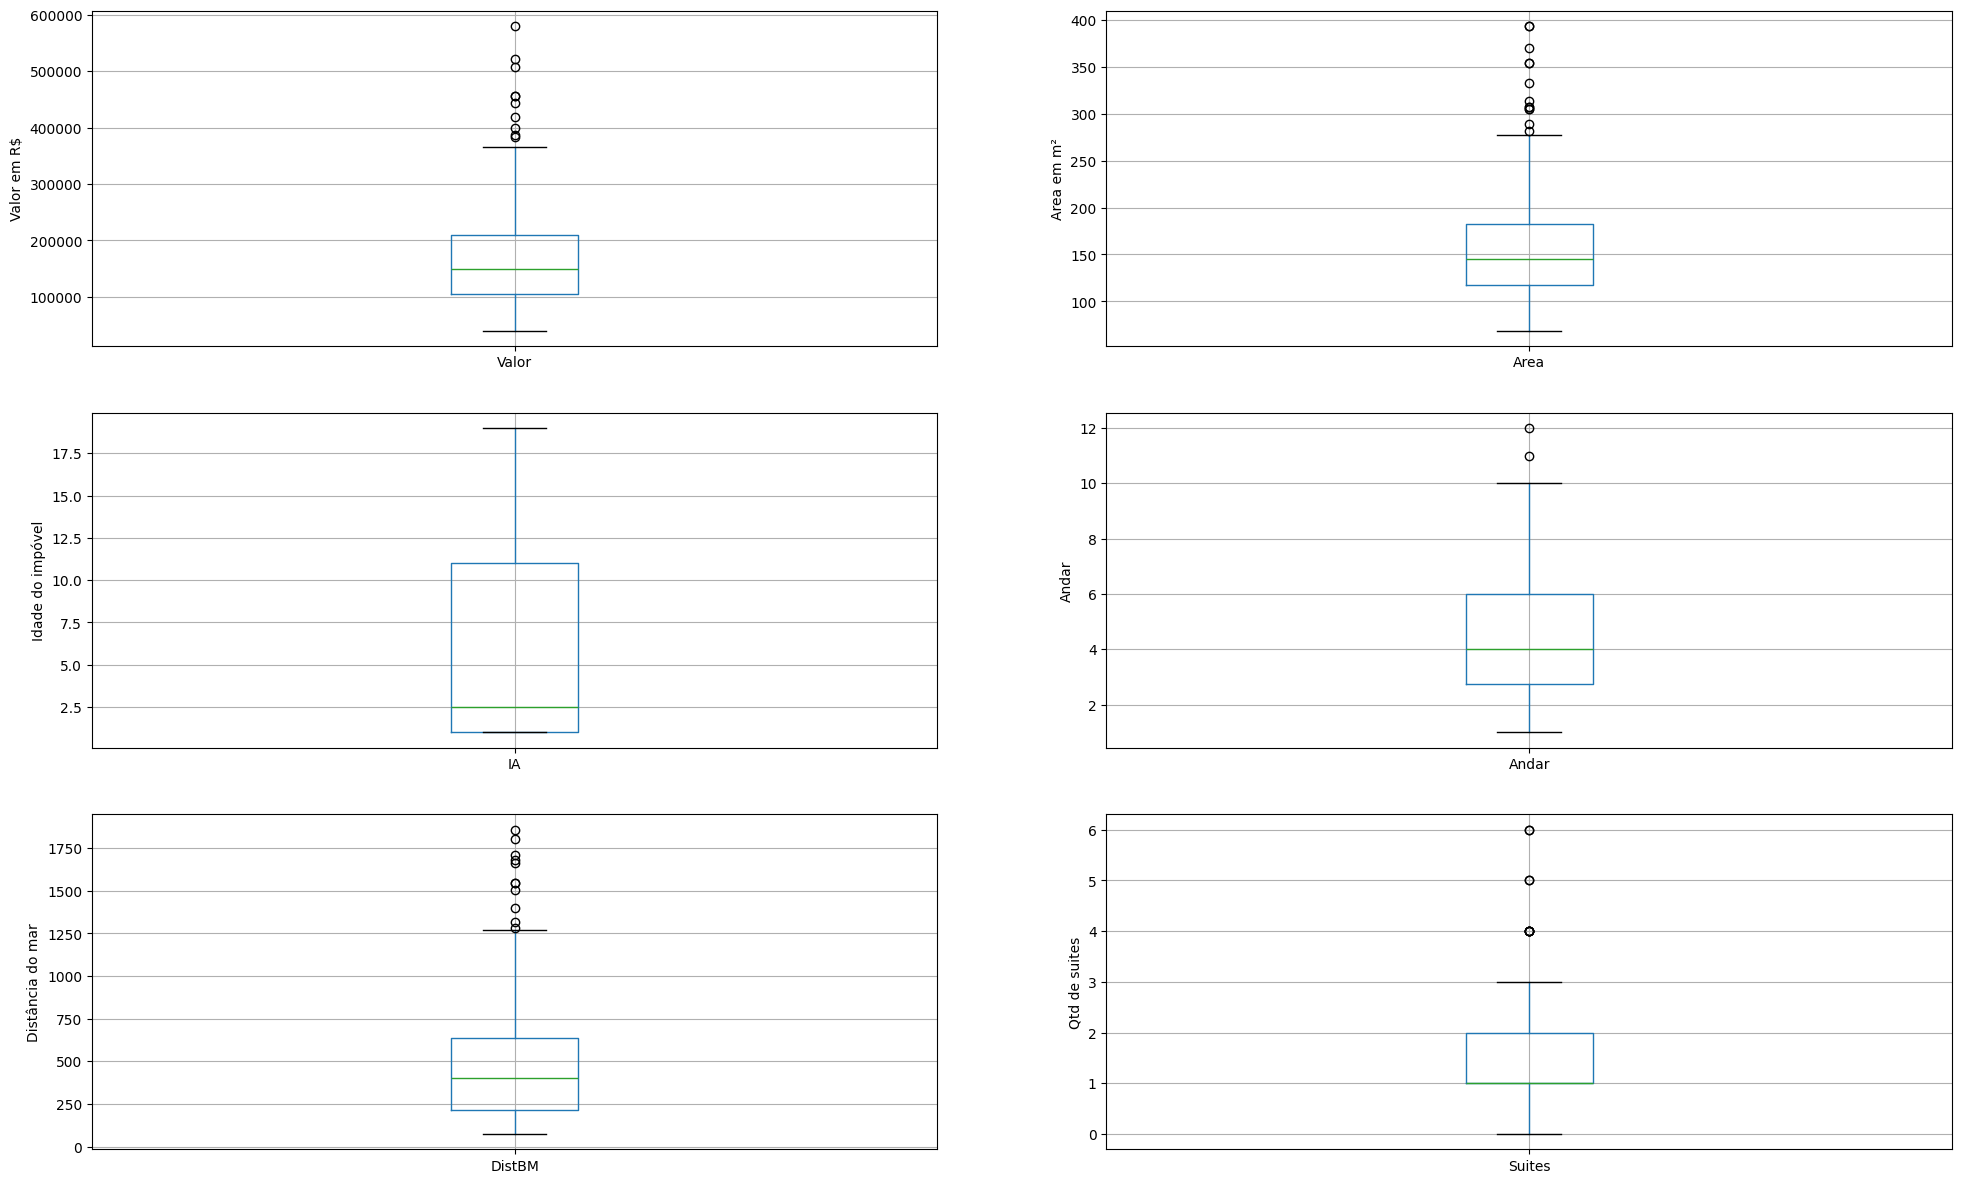

In [10]:
# Análisando as variáveis quantitativas para verificar se tem outliers
plt.figure(figsize =(24,20))

plt.subplot(4, 2, 1)
fig = imoveis.boxplot(column = "Valor")
fig.set_title("")
fig.set_ylabel("Valor em R$")

plt.subplot(4, 2, 2)
fig = imoveis.boxplot(column = "Area")
fig.set_title("")
fig.set_ylabel("Area em m²")

plt.subplot(4, 2, 3)
fig = imoveis.boxplot(column = "IA")
fig.set_title("")
fig.set_ylabel("Idade do impóvel")

plt.subplot(4, 2, 4)
fig = imoveis.boxplot(column = "Andar")
fig.set_title("")
fig.set_ylabel("Andar")

plt.subplot(4, 2, 5)
fig = imoveis.boxplot(column = "DistBM")
fig.set_title("")
fig.set_ylabel("Distância do mar")

plt.subplot(4, 2, 6)
fig = imoveis.boxplot(column = "Suites")
fig.set_title("")
fig.set_ylabel("Qtd de suites")

<Axes: >

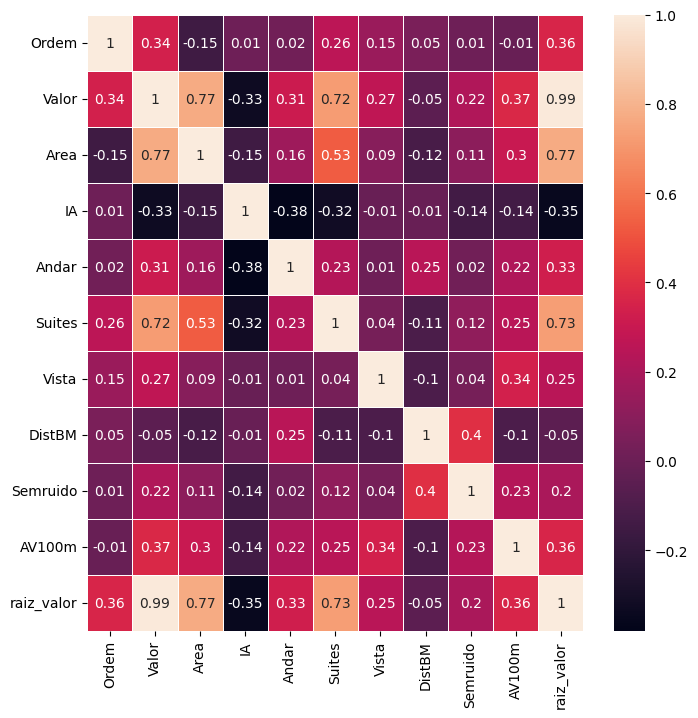

In [11]:
# Matriz de correlação entre as variáveis
correlation_matrix = imoveis.corr().round(2)

fig, ax = plt.subplots(figsize = (8,8))
sb.heatmap(data = correlation_matrix, annot= True, linewidths= .5, ax = ax)

Text(0.5, 1.0, 'Área do imóvei X valor')

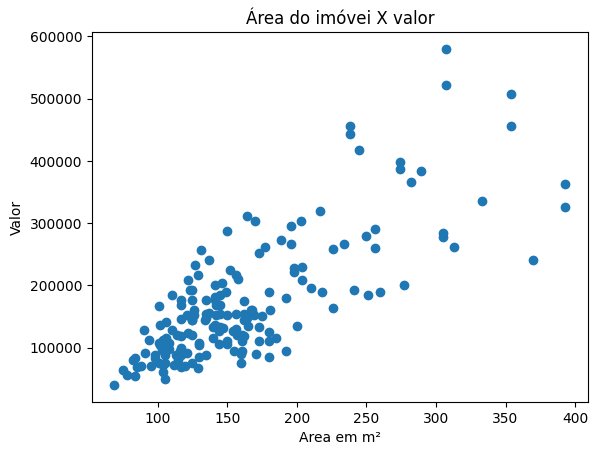

In [12]:
# Dispersão entre as variáveis
plt.scatter("Area", "Valor", data=imoveis)
plt.xlabel("Area em m²")
plt.ylabel("Valor")
plt.title("Área do imóvei X valor")

Text(0.5, 1.0, 'Idade do imóvel X valor')

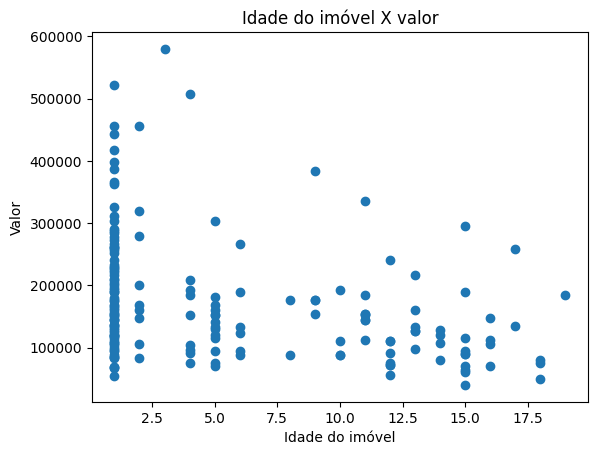

In [13]:
# Dispersão entre as variáveis
plt.scatter("IA", "Valor", data=imoveis)
plt.xlabel("Idade do imóvel")
plt.ylabel("Valor")
plt.title("Idade do imóvel X valor")

/var/folders/4v/b2nvtn6d6hq916msy3rpk8tr0000gn/T/ipykernel_1008/3655517544.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(x="Vista", y="Valor", data=imoveis, palette="hls")


<Axes: xlabel='Vista', ylabel='Valor'>

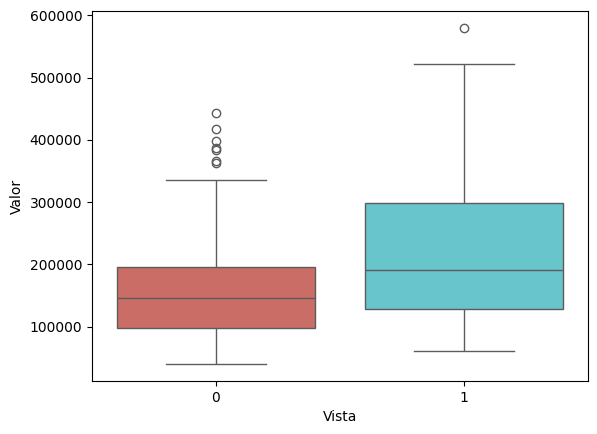

In [14]:
# Analisando as variáveis categóricas: vista X valor
sb.boxplot(x="Vista", y="Valor", data=imoveis, palette="hls")

/var/folders/4v/b2nvtn6d6hq916msy3rpk8tr0000gn/T/ipykernel_1008/3802109648.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(x="Semruido", y="Valor", data=imoveis, palette="hls")


<Axes: xlabel='Semruido', ylabel='Valor'>

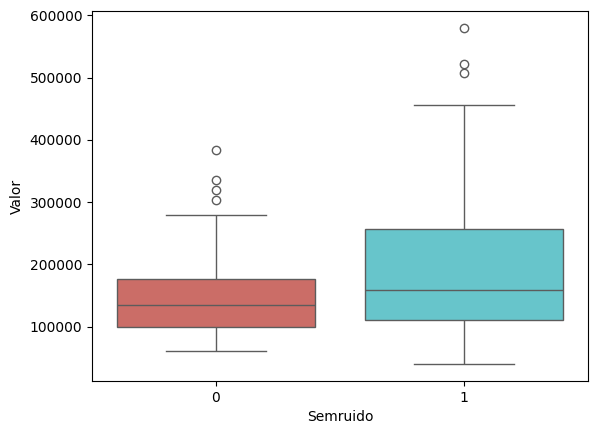

In [15]:
# Analisando as variáveis sem ruido X valor
sb.boxplot(x="Semruido", y="Valor", data=imoveis, palette="hls")

/var/folders/4v/b2nvtn6d6hq916msy3rpk8tr0000gn/T/ipykernel_1008/1709560463.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(x="AV100m", y="Valor", data=imoveis, palette="hls")


<Axes: xlabel='AV100m', ylabel='Valor'>

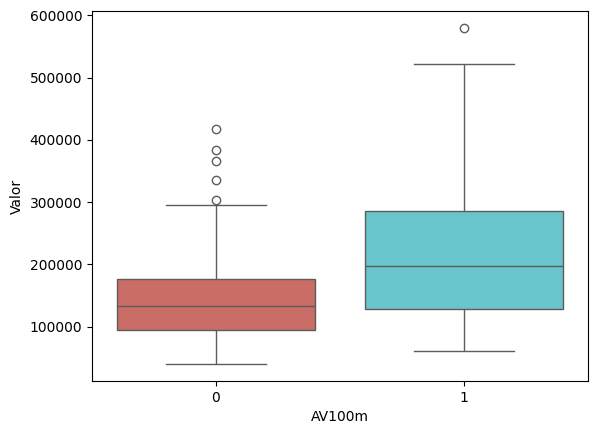

In [16]:
sb.boxplot(x="AV100m", y="Valor", data=imoveis, palette="hls")

## Criando o modelo de uma regressão linear simples

In [17]:
# Regressão linear múltipla
from sklearn.linear_model import LinearRegression

In [18]:
# Criando um objeto de regressão linear
lr = LinearRegression()

In [19]:
# X contém as variáveis preditoras ou independentes
X = imoveis[['Area', 'Suites', 'IA', 'Andar', 'DistBM', 'Vista', 'Semruido', 'AV100m']]

# Y variável TARGET ou dependente
y = imoveis[['Valor']]

In [20]:
# Dividindo os dados em treino e teste
from sklearn.model_selection import train_test_split

In [21]:
# Separando osw dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 101)

In [22]:
# Treinando o modelo
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
# Calculando o valor predito da variável resposta na amostra teste
y_pred = lr.predict(X_test)

In [24]:
# Analisando o Intercepto e os Coeficientes da Regressão
# Represena o valor esperado da variável dependente quando todas as variáveis independentes são iguais a zero
# Em termos gráficos, o intercepto é o ponto onde a linha de regressão cruza o eixo vertical (eixo y).
print('Intercepto:', lr.intercept_)

Intercepto: [-40165.8752773]


In [25]:
# Os coeficientes da regressão linear representam as inclinações da linha de regressão para cada variável independente.
coefficients = pd.concat([pd.DataFrame(X.columns), pd.DataFrame(np.transpose(lr.coef_))], axis = 1)
coefficients

,0,0
0,Area,815.218075
1,Suites,34315.785459
2,IA,-1052.417100
3,Andar,5635.237485
4,DistBM,-2.522530
5,Vista,63486.030935
6,Semruido,17027.508944
7,AV100m,-5672.535051


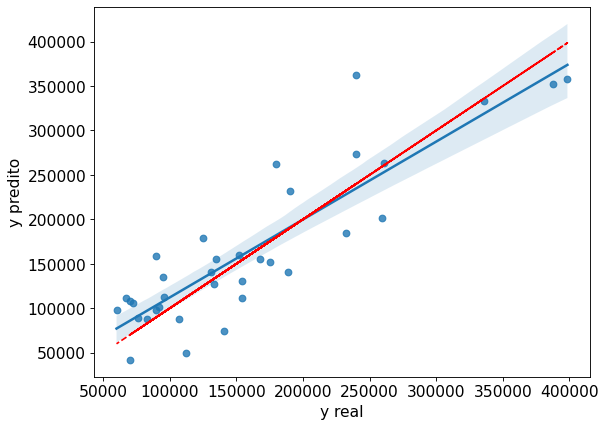

In [26]:
# Visualizando o quanto este modelo errou (predizendo os erros)
fig = plt.figure(figsize=(8, 6), dpi=80)
plt.rcParams.update({'font.size': 14})
ax = sb.regplot(x = y_test, y = y_pred)
ax.set(xlabel= 'y real', ylabel = 'y predito')
ax = plt.plot(y_test, y_test, '--r')

plt.show()

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [28]:
# Avaliando o modelo
MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('MAE', MAE) # Mean Absolute Error (MAE) é a média do valor dos erros absolutos
print('MSE', MSE) # Erro quadrático médio (MSE) é a média dos erros quadráticos
print('R²', r2) # R ao quadrado

MAE 34422.988570945854
MSE 1844288772.179021
R² 0.7584591969124989


## Avaliando com DecisionTreeRegressor (ÁRVORE DE REGRESSÃO)
### Modelo utilizado para resolver problemas de regressão que cria uma estrutura em forma de árvore para mapear relações *NÃO* lineares entre as variáveis preditoras e a variável alvo.

In [29]:
from sklearn.tree import DecisionTreeRegressor

In [30]:
# Criando o modelo de DecisionTreeRegressor
model_dtr = DecisionTreeRegressor(random_state=101, max_depth=10) # Quantidade de ramificações da árvore

# Treinando o modelo
model_dtr.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",101
,"max_le

In [31]:
y_pred_model_dtr = model_dtr.predict(X_test)

In [32]:
# Avaliando o modelo
MAE = mean_absolute_error(y_test, y_pred_model_dtr)
MSE = mean_squared_error(y_test, y_pred_model_dtr)
r2 = r2_score(y_test, y_pred_model_dtr)

print('MAE', MAE) # Mean Absolute Error (MAE) é a média do valor dos erros absolutos
print('MSE', MSE) # Erro quadrático médio (MSE) é a média dos erros quadráticos
print('R²', r2) # R ao quadrado 

MAE 45516.60816326531
MSE 3427174025.4991255
R² 0.5511536051582436


## Avaliando com SVR
### Support Vector Regression, é usado para tarefas de regressão, onde o foco dele é prever um valor contínuo em vez de uma classe

In [33]:
from sklearn.svm import SVR

In [34]:
# Criando o mdelo de SVR
svr = SVR(kernel='linear')

In [35]:
# Treinando o modelo
svr.fit(X_train, y_train)

/Users/danna.bigois/.pyenv/versions/3.13.13/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [36]:
# Calculando o valor predito da variável resposta na amostra teste
y_pred_svr = svr.predict(X_test)

In [37]:
# Avaliando o modelo
MAE = mean_absolute_error(y_test, y_pred_svr)
MSE = mean_squared_error(y_test, y_pred_svr)
r2 = r2_score(y_test, y_pred_svr)

print('MAE', MAE) # Mean Absolute Error (MAE) é a média do valor dos erros absolutos
print('MSE', MSE) # Erro quadrático médio (MSE) é a média dos erros quadráticos
print('R²', r2) # R ao quadrado 

MAE 43153.53918496288
MSE 3123421996.7782364
R² 0.5909350700044546
